<a href="https://colab.research.google.com/github/24cseaiml025puspanjalinayak-spec/DMPM-LAB/blob/main/DMPM_Lab7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Cluster Labels:
[1 1 1 0 0 0]

 Cluster Centers:
[[11.         11.33333333]
 [ 3.          3.33333333]]


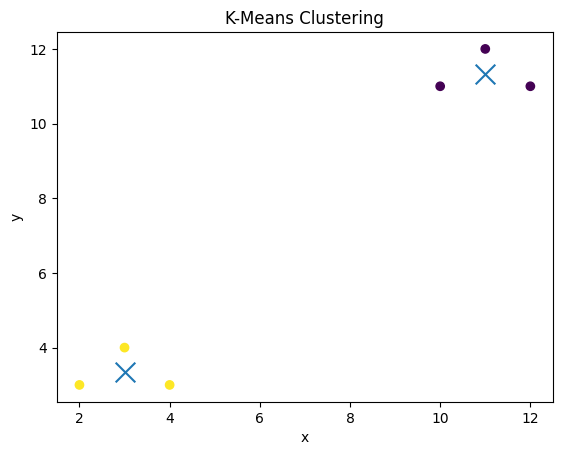

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import  KMeans

#sample data
x= np.array([
    [2,3],
    [3,4],
    [4,3],
    [10,11],
    [11,12],
    [12,11]
])


#apply kmeans
Kmeans= KMeans(n_clusters=2, random_state=0, n_init=10)
labels=Kmeans.fit_predict(x)

#display cluster information
print("Cluster Labels:")
print(labels)
print("\n Cluster Centers:")
print(Kmeans.cluster_centers_)

#plot clusters
plt.scatter(x[:,0], x[:,1], c=labels)
plt.scatter(
    Kmeans.cluster_centers_[:,0],
    Kmeans.cluster_centers_[:,1],
    marker='x',
    s=200
)
plt.xlabel("x")
plt.ylabel("y")
plt.title("K-Means Clustering")
plt.show()

cluster labels:
[0 0 0 1 1 1]

medoid points
[3 4]
[11 12]


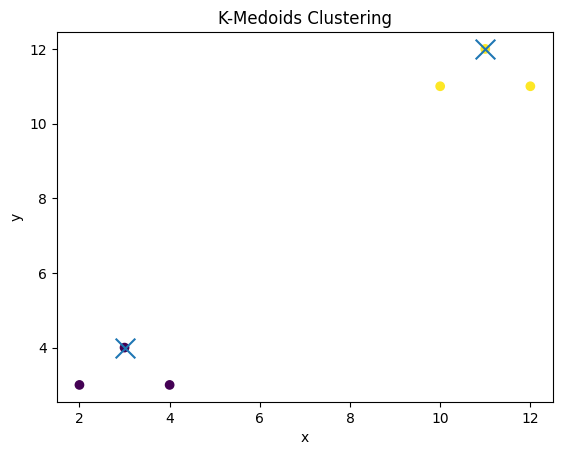

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

x= np.array([
    [2,3],
    [3,4],
    [4,3],
    [10,11],
    [11,12],
    [12,11]
])
k=2
medoid_indices=[0, 3]

while True:
  # Step 1: Assign each data point to the closest medoid
  distances = np.zeros((len(x),k))
  for i in range(len(x)): # Iterate through data points
    for j in range(k): # Iterate through current medoids
      distances[i,j]=np.linalg.norm(x[i]-x[medoid_indices[j]])
  labels = np.argmin(distances, axis=1)

  # Step 2: Update medoids
  new_medoid_indices_for_iteration = []
  for cluster in range(k):
    cluster_indices=np.where(labels==cluster)[0] # Get indices of points in the current cluster

    if len(cluster_indices)==0:
      # If a cluster is empty, keep its old medoid
      new_medoid_indices_for_iteration.append(medoid_indices[cluster])
      continue

    # For non-empty clusters, find the point that minimizes sum of distances to other points in the cluster
    total_distances_in_cluster = []
    for p_idx_i in cluster_indices:
      total_dist_from_current_point = 0
      for p_idx_j in cluster_indices:
        total_dist_from_current_point += np.linalg.norm(x[p_idx_i] - x[p_idx_j])
      total_distances_in_cluster.append(total_dist_from_current_point)

    # The new medoid is the point (from original `x`) that minimizes total_distances_in_cluster
    new_medoid_indices_for_iteration.append(cluster_indices[np.argmin(total_distances_in_cluster)])

  # Step 3: Check for convergence
  # Sort both lists for a consistent comparison
  current_medoid_indices_sorted = sorted(medoid_indices)
  new_medoid_indices_for_iteration_sorted = sorted(new_medoid_indices_for_iteration)

  if new_medoid_indices_for_iteration_sorted == current_medoid_indices_sorted:
    break # Algorithm converged

  medoid_indices = new_medoid_indices_for_iteration # Update medoid_indices for the next iteration


# Display final cluster information and plot
print("cluster labels:")
print(labels)

print("\nmedoid points")
for index in medoid_indices:
  print(x[index])

plt.scatter(x[:,0], x[:,1], c=labels)
medoids=x[medoid_indices]
plt.scatter(
    medoids[:,0],
    medoids[:,1],
    marker='x',
    s=200
    )
plt.xlabel("x")
plt.ylabel("y")
plt.title("K-Medoids Clustering")
plt.show()